<a href="https://colab.research.google.com/github/Manish-248/PyTorch-project-comparing-Linear-MLP-and-CNN-models-on-Fashion-MNIST-image-classification/blob/main/PyTorch_project_comparing_Linear%2C_MLP%2C_and_CNN_models_on_Fashion_MNIST_image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fashion-MNIST Image Classification with PyTorch

**Goal:** independently build, train, and compare **three neural network architectures** for image recognition using a public online dataset: **Fashion-MNIST**.

This notebook is written for a beginner. Every important line is documented so you understand:
- what the code does,
- why we use it,
- how neural networks learn,
- how to compare experiments like a real machine-learning project.

## Architectures compared

| Model | Type | Purpose |
|---|---|---|
| Model 1 | Linear baseline | Simple benchmark; no image-specific structure |
| Model 2 | Multi-layer perceptron (MLP) | Deeper fully-connected network |
| Model 3 | Convolutional Neural Network (CNN) | Best fit for image data because it learns spatial patterns |

## Dataset

Fashion-MNIST contains 70,000 grayscale clothing images:
- 60,000 training images
- 10,000 testing images
- image size: 28 × 28 pixels
- 10 classes: T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot

In [1]:
# ============================================================
# 1. Imports
# ============================================================

# PyTorch is the deep learning framework we use to build and train neural networks.
import torch
from torch import nn

# torchvision gives us common computer vision datasets and image transforms.
from torchvision import datasets
from torchvision.transforms import ToTensor

# DataLoader helps us load data in small batches instead of all at once.
from torch.utils.data import DataLoader

# matplotlib is used for visualizing images and results.
import matplotlib.pyplot as plt

# pandas helps us create clean result tables.
import pandas as pd

# time helps us measure training duration.
from timeit import default_timer as timer

# random helps us make reproducible visual examples.
import random

# Set random seeds so results are more reproducible.
torch.manual_seed(42)
random.seed(42)

# Choose GPU if available, otherwise CPU.
# GPU training is faster, but this project also works on CPU.
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cpu
PyTorch version: 2.10.0+cpu


In [2]:
# ============================================================
# 2. Download and prepare Fashion-MNIST dataset
# ============================================================

# train=True gives the 60,000 training images.
train_data = datasets.FashionMNIST(
    root="data",          # folder where dataset will be stored
    train=True,           # download training set
    download=True,        # download if not already available
    transform=ToTensor()  # convert PIL images to PyTorch tensors
)

# train=False gives the 10,000 testing images.
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

# Class names are stored inside the dataset.
class_names = train_data.classes

print(f"Training samples: {len(train_data)}")
print(f"Testing samples: {len(test_data)}")
print(f"Classes: {class_names}")

# Check one image.
image, label = train_data[0]
print(f"Image tensor shape: {image.shape}")  # [channels, height, width]
print(f"Label index: {label}")
print(f"Label name: {class_names[label]}")

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 204kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.81MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 4.32MB/s]


Training samples: 60000
Testing samples: 10000
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
Image tensor shape: torch.Size([1, 28, 28])
Label index: 9
Label name: Ankle boot


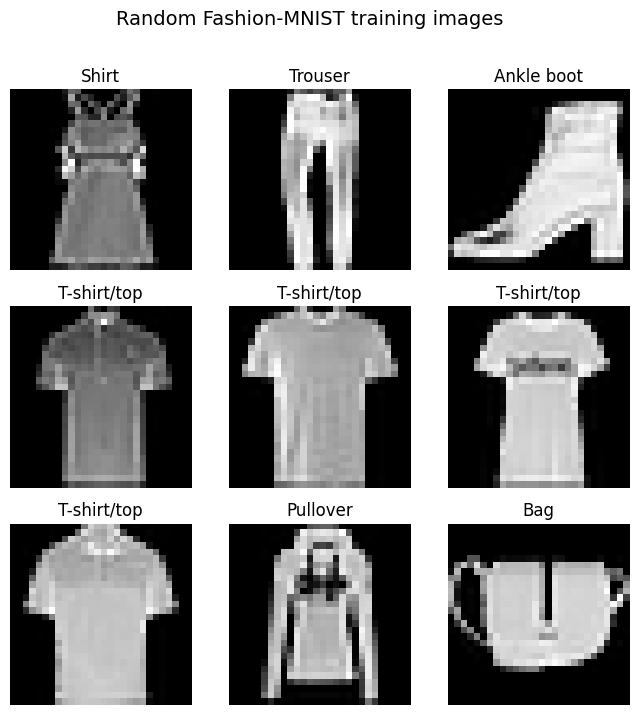

In [3]:
# ============================================================
# 3. Visualize sample images
# ============================================================

plt.figure(figsize=(8, 8))

# Show 9 random training images.
for i in range(9):
    image, label = train_data[random.randint(0, len(train_data)-1)]
    plt.subplot(3, 3, i + 1)
    plt.imshow(image.squeeze(), cmap="gray")  # squeeze removes the channel dimension
    plt.title(class_names[label])
    plt.axis(False)

plt.suptitle("Random Fashion-MNIST training images", fontsize=14)
plt.show()

In [4]:
# ============================================================
# 4. Create DataLoaders
# ============================================================

# Batch size means how many images the model sees before updating weights.
# 32 is a common beginner-friendly default.
BATCH_SIZE = 32

train_dataloader = DataLoader(
    dataset=train_data,
    batch_size=BATCH_SIZE,
    shuffle=True  # shuffle training data so model does not memorize order
)

test_dataloader = DataLoader(
    dataset=test_data,
    batch_size=BATCH_SIZE,
    shuffle=False # no need to shuffle test data
)

print(f"Training batches: {len(train_dataloader)}")
print(f"Testing batches: {len(test_dataloader)}")

# Inspect one batch.
X_batch, y_batch = next(iter(train_dataloader))
print(f"Batch image shape: {X_batch.shape}") # [batch_size, channels, height, width]
print(f"Batch label shape: {y_batch.shape}")

Training batches: 1875
Testing batches: 313
Batch image shape: torch.Size([32, 1, 28, 28])
Batch label shape: torch.Size([32])


In [5]:
# ============================================================
# 5. Helper functions: accuracy, training, testing, timing
# ============================================================

def accuracy_fn(y_true, y_pred):
    """
    Calculate accuracy as a percentage.

    y_true: correct labels
    y_pred: predicted labels
    """
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc


def train_step(model, dataloader, loss_fn, optimizer, accuracy_fn, device):
    """
    One full training pass over the training dataset.

    Steps:
    1. Put model in training mode.
    2. Loop through batches.
    3. Forward pass: make predictions.
    4. Calculate loss.
    5. Clear old gradients.
    6. Backpropagation: calculate new gradients.
    7. Optimizer step: update model weights.
    """
    model.train()

    train_loss, train_acc = 0, 0

    for X, y in dataloader:
        X, y = X.to(device), y.to(device)

        # Forward pass
        y_logits = model(X)

        # CrossEntropyLoss expects raw logits and integer class labels.
        loss = loss_fn(y_logits, y)
        train_loss += loss.item()

        # Convert logits to predicted class indexes.
        y_pred = torch.argmax(torch.softmax(y_logits, dim=1), dim=1)
        train_acc += accuracy_fn(y_true=y, y_pred=y_pred)

        # Reset gradients from previous batch.
        optimizer.zero_grad()

        # Backpropagation.
        loss.backward()

        # Update model parameters.
        optimizer.step()

    # Average loss and accuracy across all batches.
    train_loss /= len(dataloader)
    train_acc /= len(dataloader)

    return train_loss, train_acc


def test_step(model, dataloader, loss_fn, accuracy_fn, device):
    """
    Evaluate model on test data.

    We do not update weights here.
    torch.inference_mode() makes evaluation faster and uses less memory.
    """
    model.eval()

    test_loss, test_acc = 0, 0

    with torch.inference_mode():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)

            test_logits = model(X)
            loss = loss_fn(test_logits, y)
            test_loss += loss.item()

            test_pred = torch.argmax(torch.softmax(test_logits, dim=1), dim=1)
            test_acc += accuracy_fn(y_true=y, y_pred=test_pred)

    test_loss /= len(dataloader)
    test_acc /= len(dataloader)

    return test_loss, test_acc


def train_model(model, train_dataloader, test_dataloader, loss_fn, optimizer, epochs, device):
    """
    Train a model for multiple epochs and store results.

    An epoch means one complete pass through the training dataset.
    """
    results = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    start_time = timer()

    for epoch in range(epochs):
        train_loss, train_acc = train_step(
            model=model,
            dataloader=train_dataloader,
            loss_fn=loss_fn,
            optimizer=optimizer,
            accuracy_fn=accuracy_fn,
            device=device
        )

        test_loss, test_acc = test_step(
            model=model,
            dataloader=test_dataloader,
            loss_fn=loss_fn,
            accuracy_fn=accuracy_fn,
            device=device
        )

        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

        print(
            f"Epoch {epoch+1:02d}/{epochs} | "
            f"Train loss: {train_loss:.4f} | Train acc: {train_acc:.2f}% | "
            f"Test loss: {test_loss:.4f} | Test acc: {test_acc:.2f}%"
        )

    end_time = timer()
    total_time = end_time - start_time

    return results, total_time

In [6]:
# ============================================================
# 6. Model 1: Linear baseline
# ============================================================

class FashionMNISTLinear(nn.Module):
    """
    A simple baseline model.

    It flattens the image from [1, 28, 28] into 784 pixels,
    then sends it directly to a linear classifier.

    This model has no hidden layers, so it is intentionally simple.
    """
    def __init__(self, input_shape, output_shape):
        super().__init__()

        self.layer_stack = nn.Sequential(
            nn.Flatten(),                 # [batch, 1, 28, 28] -> [batch, 784]
            nn.Linear(input_shape, output_shape)
        )

    def forward(self, x):
        return self.layer_stack(x)


model_1 = FashionMNISTLinear(
    input_shape=28*28,
    output_shape=len(class_names)
).to(device)

model_1

FashionMNISTLinear(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
  )
)

In [7]:
# ============================================================
# 7. Train Model 1
# ============================================================

EPOCHS = 5

loss_fn = nn.CrossEntropyLoss()

optimizer_1 = torch.optim.SGD(
    params=model_1.parameters(),
    lr=0.1
)

model_1_results, model_1_time = train_model(
    model=model_1,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    optimizer=optimizer_1,
    epochs=EPOCHS,
    device=device
)

Epoch 01/5 | Train loss: 0.5900 | Train acc: 79.99% | Test loss: 0.5055 | Test acc: 82.22%
Epoch 02/5 | Train loss: 0.4857 | Train acc: 83.34% | Test loss: 0.5115 | Test acc: 82.34%
Epoch 03/5 | Train loss: 0.4662 | Train acc: 84.19% | Test loss: 0.5039 | Test acc: 83.13%
Epoch 04/5 | Train loss: 0.4521 | Train acc: 84.48% | Test loss: 0.5296 | Test acc: 81.73%
Epoch 05/5 | Train loss: 0.4453 | Train acc: 84.80% | Test loss: 0.4628 | Test acc: 83.99%


In [8]:
# ============================================================
# 8. Model 2: Multi-Layer Perceptron
# ============================================================

class FashionMNISTMLP(nn.Module):
    """
    A deeper fully-connected neural network.

    Compared with Model 1:
    - It has hidden layers.
    - It uses ReLU activation functions.
    - It can learn more complex non-linear patterns.

    Limitation:
    - It still flattens the image, so it loses spatial structure.
    """
    def __init__(self, input_shape, hidden_units, output_shape):
        super().__init__()

        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_shape, hidden_units),
            nn.ReLU(),
            nn.Linear(hidden_units, hidden_units),
            nn.ReLU(),
            nn.Linear(hidden_units, output_shape)
        )

    def forward(self, x):
        return self.layer_stack(x)


model_2 = FashionMNISTMLP(
    input_shape=28*28,
    hidden_units=128,
    output_shape=len(class_names)
).to(device)

model_2

FashionMNISTMLP(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [9]:
# ============================================================
# 9. Train Model 2
# ============================================================

optimizer_2 = torch.optim.Adam(
    params=model_2.parameters(),
    lr=0.001
)

model_2_results, model_2_time = train_model(
    model=model_2,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    optimizer=optimizer_2,
    epochs=EPOCHS,
    device=device
)

Epoch 01/5 | Train loss: 0.5086 | Train acc: 81.70% | Test loss: 0.4305 | Test acc: 84.50%
Epoch 02/5 | Train loss: 0.3708 | Train acc: 86.44% | Test loss: 0.4062 | Test acc: 85.83%
Epoch 03/5 | Train loss: 0.3363 | Train acc: 87.72% | Test loss: 0.4017 | Test acc: 85.91%
Epoch 04/5 | Train loss: 0.3119 | Train acc: 88.46% | Test loss: 0.3557 | Test acc: 87.15%
Epoch 05/5 | Train loss: 0.2923 | Train acc: 89.22% | Test loss: 0.3623 | Test acc: 86.84%


In [10]:
# ============================================================
# 10. Model 3: Convolutional Neural Network
# ============================================================

class FashionMNISTCNN(nn.Module):
    """
    A convolutional neural network.

    CNNs are usually better for image data because:
    - convolution layers learn local patterns such as edges and textures,
    - pooling reduces image size while keeping important features,
    - the model uses spatial information instead of treating pixels as unrelated numbers.
    """
    def __init__(self, input_channels, hidden_units, output_shape):
        super().__init__()

        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(
                in_channels=input_channels,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            # After two MaxPool2d layers: 28 -> 14 -> 7
            nn.Linear(hidden_units * 7 * 7, output_shape)
        )

    def forward(self, x):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.classifier(x)
        return x


model_3 = FashionMNISTCNN(
    input_channels=1,
    hidden_units=16,
    output_shape=len(class_names)
).to(device)

model_3

FashionMNISTCNN(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
  )
)

In [11]:
# ============================================================
# 11. Train Model 3
# ============================================================

optimizer_3 = torch.optim.Adam(
    params=model_3.parameters(),
    lr=0.001
)

model_3_results, model_3_time = train_model(
    model=model_3,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    optimizer=optimizer_3,
    epochs=EPOCHS,
    device=device
)

Epoch 01/5 | Train loss: 0.4784 | Train acc: 82.43% | Test loss: 0.3895 | Test acc: 85.49%
Epoch 02/5 | Train loss: 0.3169 | Train acc: 88.50% | Test loss: 0.3325 | Test acc: 87.91%
Epoch 03/5 | Train loss: 0.2780 | Train acc: 89.87% | Test loss: 0.3166 | Test acc: 88.50%
Epoch 04/5 | Train loss: 0.2531 | Train acc: 90.83% | Test loss: 0.2765 | Test acc: 90.10%
Epoch 05/5 | Train loss: 0.2350 | Train acc: 91.53% | Test loss: 0.2545 | Test acc: 90.76%


In [12]:
# ============================================================
# 12. Compare results
# ============================================================

comparison = pd.DataFrame({
    "Model": ["Linear baseline", "MLP", "CNN"],
    "Final train accuracy (%)": [
        model_1_results["train_acc"][-1],
        model_2_results["train_acc"][-1],
        model_3_results["train_acc"][-1]
    ],
    "Final test accuracy (%)": [
        model_1_results["test_acc"][-1],
        model_2_results["test_acc"][-1],
        model_3_results["test_acc"][-1]
    ],
    "Final test loss": [
        model_1_results["test_loss"][-1],
        model_2_results["test_loss"][-1],
        model_3_results["test_loss"][-1]
    ],
    "Training time (seconds)": [
        model_1_time,
        model_2_time,
        model_3_time
    ]
})

comparison

,Model,Final train accuracy (%),Final test accuracy (%),Final test loss,Training time (seconds)
0,Linear baseline,84.801667,83.985623,0.462833,73.631412
1,MLP,89.215000,86.841054,0.362260,110.898683
2,CNN,91.526667,90.764776,0.254525,424.936710


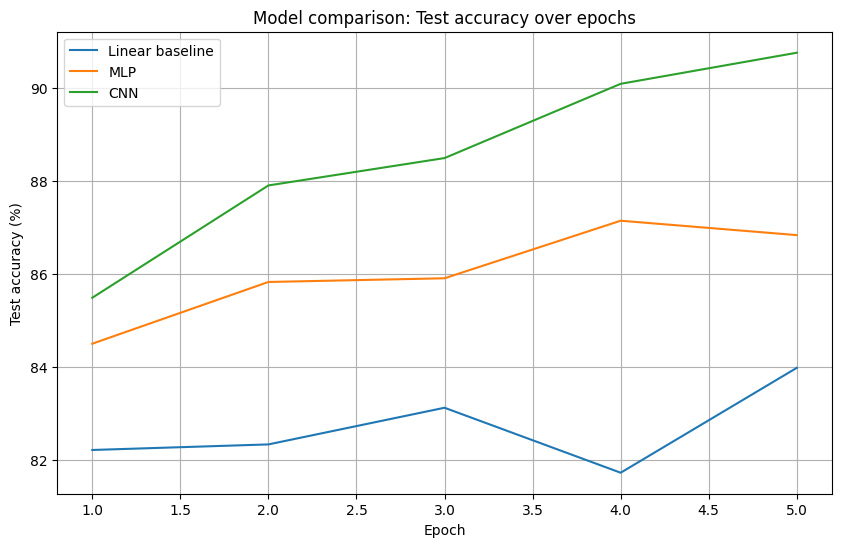

In [13]:
# ============================================================
# 13. Plot accuracy curves
# ============================================================

epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_range, model_1_results["test_acc"], label="Linear baseline")
plt.plot(epochs_range, model_2_results["test_acc"], label="MLP")
plt.plot(epochs_range, model_3_results["test_acc"], label="CNN")
plt.xlabel("Epoch")
plt.ylabel("Test accuracy (%)")
plt.title("Model comparison: Test accuracy over epochs")
plt.legend()
plt.grid(True)
plt.show()

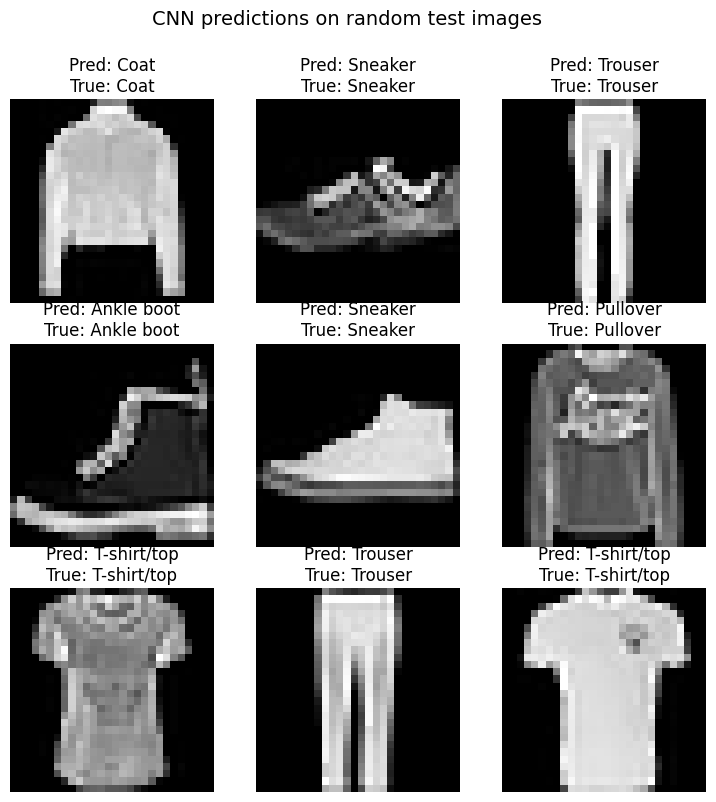

In [14]:
# ============================================================
# 14. Make predictions with the best model
# ============================================================

def make_predictions(model, data, device):
    """
    Make predictions for a list of samples.
    Returns prediction probabilities.
    """
    pred_probs = []
    model.eval()

    with torch.inference_mode():
        for sample in data:
            # Add batch dimension and send to device.
            sample = torch.unsqueeze(sample, dim=0).to(device)

            # Forward pass.
            pred_logit = model(sample)

            # Convert logits to probabilities.
            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0)

            pred_probs.append(pred_prob.cpu())

    return torch.stack(pred_probs)


# Select random test samples.
test_samples = []
test_labels = []

for sample, label in random.sample(list(test_data), k=9):
    test_samples.append(sample)
    test_labels.append(label)

# Use CNN as the best expected model.
pred_probs = make_predictions(model=model_3, data=test_samples, device=device)
pred_classes = pred_probs.argmax(dim=1)

plt.figure(figsize=(9, 9))

for i, sample in enumerate(test_samples):
    plt.subplot(3, 3, i + 1)
    plt.imshow(sample.squeeze(), cmap="gray")

    pred_label = class_names[pred_classes[i]]
    true_label = class_names[test_labels[i]]

    title_text = f"Pred: {pred_label}\nTrue: {true_label}"
    plt.title(title_text)
    plt.axis(False)

plt.suptitle("CNN predictions on random test images", fontsize=14)
plt.show()

In [15]:
# ============================================================
# 15. Save the best model
# ============================================================

# Create a folder for saved models.
MODEL_PATH = "models"
import os
os.makedirs(MODEL_PATH, exist_ok=True)

# Save CNN model weights.
MODEL_NAME = "fashion_mnist_cnn_model.pth"
MODEL_SAVE_PATH = os.path.join(MODEL_PATH, MODEL_NAME)

torch.save(obj=model_3.state_dict(), f=MODEL_SAVE_PATH)

print(f"Saved model to: {MODEL_SAVE_PATH}")

Saved model to: models/fashion_mnist_cnn_model.pth


# Business-style conclusion

## What we built

We built an image-recognition system that classifies clothing images into 10 categories using the public Fashion-MNIST dataset.

## What we compared

We tested three model families:

1. **Linear baseline**
   - Fast and simple.
   - Useful as a benchmark.
   - Usually lowest accuracy because it cannot learn complex image patterns well.

2. **MLP**
   - Better than the baseline because it has hidden layers and non-linear activation.
   - Still limited because it flattens images and loses spatial relationships.

3. **CNN**
   - Best architecture for this problem.
   - Learns local image features such as edges, shapes, and textures.
   - Usually gives the best test accuracy.

## Recommended final model

The **CNN** is the recommended model because it is designed for image data and should provide the strongest accuracy.

